In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
data=pd.read_csv("stores_sales_forecasting.csv", encoding='cp1256')
df=data.copy()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [35]:
df.columns

"""
 
Row ID	        رقم تسلسلي لكل صف (معرف داخلي للجدول).
Order ID	    رقم تعريف الطلبية (كل طلبية لها رقم فريد).
Order Date	    تاريخ إصدار الطلبية من العميل.
Ship Date	    تاريخ شحن الطلبية من المخزن.
Ship Mode	    طريقة الشحن .
Customer ID	    معرف العميل الفريد في قاعدة البيانات.
Customer Name	اسم العميل الذي قام بالطلب.
Segment	        فئة العميل   .
Country	        اسم الدولة التي تمت فيها الطلبية.
City	        اسم المدينة التي تم فيها الطلبية.
Postal Code	    الرمز البريدي للمدينة/الموقع.
Region	        المنطقة الجغرافية داخل الدولة .
Product ID	    رقم تعريف المنتج الفريد.
Category	    فئة المنتج الرئيسية .
Sub-Category	الفئة الفرعية للمنتج داخل الفئة الرئيسية .
Product Name	اسم المنتج الكامل والوصف التفصيلي.
Sales	        قيمة المبيعات (بالعملة المستخدمة في الملف غالبًا بالدولار).
Quantity	    عدد الوحدات المباعة من المنتج.
Discount	    نسبة الخصم المطبقة على المنتج .
Profit	        الربح الصافي الناتج من هذه الصفقة بعد الخصم والتكاليف.

"""
"""
الغرض من التحليل هو 

1.تحديد العوامل المواثره علي الربح 
2.تحديد العوامل المواثره علي المبيعات
3.التنباء بالربح والمبيعات بناء علي العوامل المواثره

"""

'\nالغرض من التحليل هو \n\n1.تحديد العوامل المواثره علي الربح \n2.تحديد العوامل المواثره علي المبيعات\n3.التنباء بالربح والمبيعات بناء علي العوامل المواثره\n\n'

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [37]:
df.isnull().sum()
print(df.nunique())
"""
ملاحظات 

عندنا اربع انواع من طرق التوصيل دا عامل قد يكون ماثر 
عندنا 707 رقم للعميل وعندنا 707 اسم عميل معني كدا ان العملاء كلهم مختلفين عنبعض 
اكيد فئة العميل عامل مواثر 
الدوله فيها متغير واحد يبقي يتحذف العمود دا 
المنطقه الجغرافيه اكيد مهما معنانا
التصنيف في عنصر واحد يتحذف 
المعم معنا التصنيف الفرعي 


"""

Row ID           2121
Order ID         1764
Order Date        889
Ship Date         960
Ship Mode           4
Customer ID       707
Customer Name     707
Segment             3
Country             1
City              371
State              48
Postal Code       454
Region              4
Product ID        375
Category            1
Sub-Category        4
Product Name      380
Sales            1636
Quantity           14
Discount           11
Profit           1777
dtype: int64


'\nملاحظات \n\nعندنا اربع انواع من طرق التوصيل دا عامل قد يكون ماثر \nعندنا 707 رقم للعميل وعندنا 707 اسم عميل معني كدا ان العملاء كلهم مختلفين عنبعض \nاكيد فئة العميل عامل مواثر \nالدوله فيها متغير واحد يبقي يتحذف العمود دا \nالمنطقه الجغرافيه اكيد مهما معنانا\nالتصنيف في عنصر واحد يتحذف \nالمعم معنا التصنيف الفرعي \n\n\n'

In [38]:
'''with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df["Postal Code"])
    print(df["Product Name"])'''

'with pd.option_context(\'display.max_rows\', None, \'display.max_columns\', None):\n    print(df["Postal Code"])\n    print(df["Product Name"])'

In [39]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,5041.643564,55726.556341,349.834887,3.785007,0.173923,8.699327
std,2885.740258,32261.888225,503.179145,2.251620,0.181547,136.049246
min,1.000000,1040.000000,1.892000,1.000000,0.000000,-1862.312400
25%,2568.000000,22801.000000,47.040000,2.000000,0.000000,-12.849000
50%,5145.000000,60505.000000,182.220000,3.000000,0.200000,7.774800
75%,7534.000000,90032.000000,435.168000,5.000000,0.300000,33.726600
max,9991.000000,99301.000000,4416.174000,14.000000,0.700000,1013.127000


In [40]:
df.duplicated().sum()
#df.drop(columns=["Row ID","Country","Category"], inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [41]:
#تعديل نوع البيانات لتريخ 
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
print(df["Ship Date"].iloc[10]-df["Order Date"].iloc[10])
df["Shipping Time"]=(df["Ship Date"]-df["Order Date"]).dt.days
df.head()

4 days 00:00:00


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,5
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,5


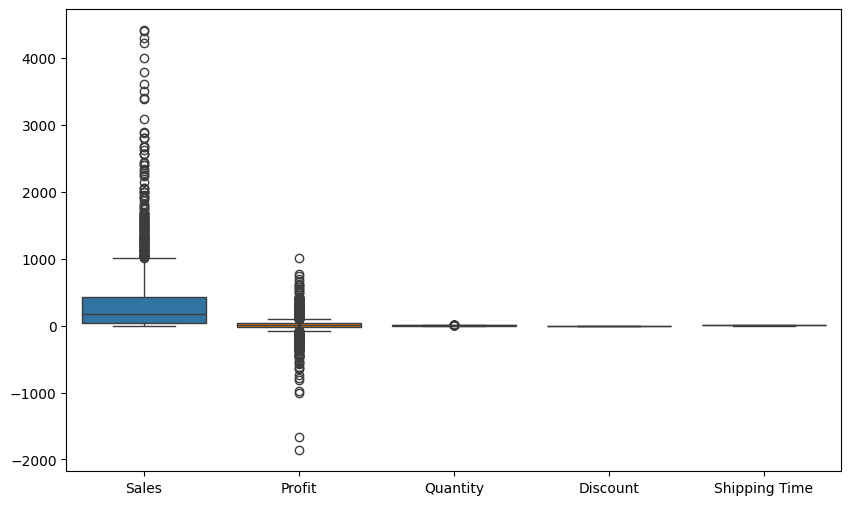

In [42]:
#اكتشاف القيم الشاذه 
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["Sales", "Profit","Quantity","Discount","Shipping Time"]])
plt.show()

<Axes: xlabel='Profit', ylabel='Count'>

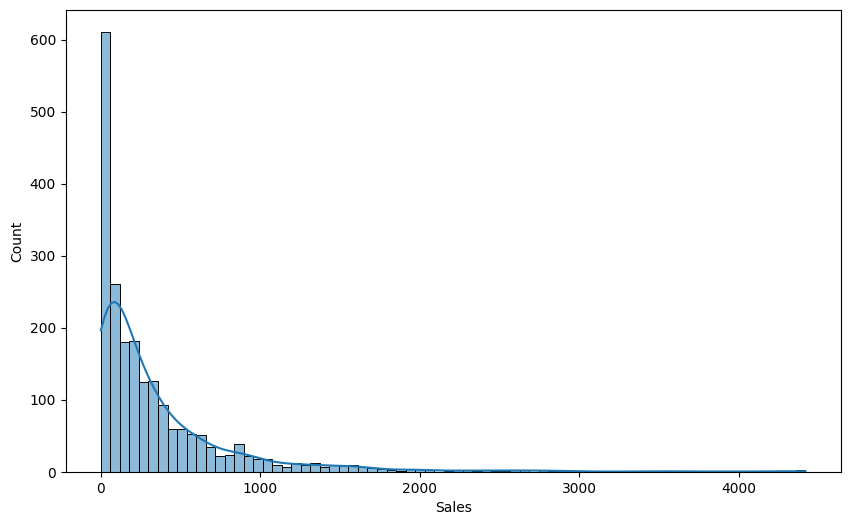

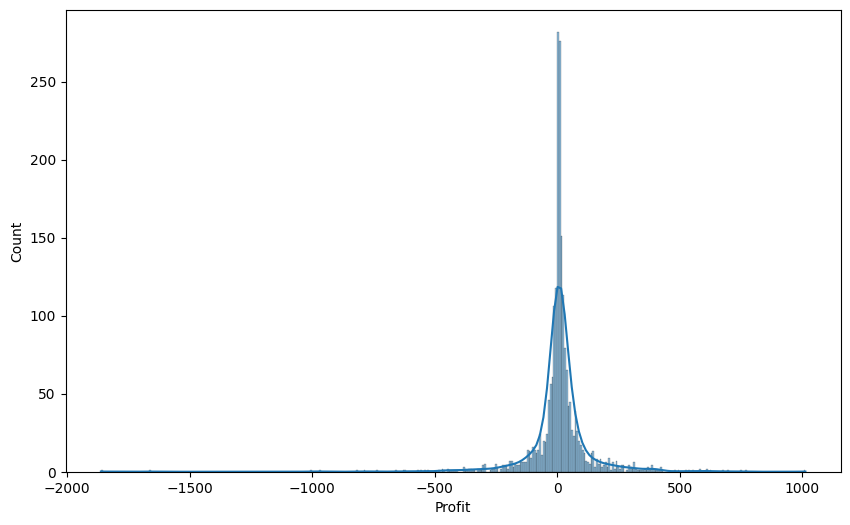

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Sales", kde=True)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Profit", kde=True)
#هو في قيم شاذه واضحه بس ممكن تكون دي فعلا المبيعات و المكسب


<Axes: xlabel='Ship Mode'>

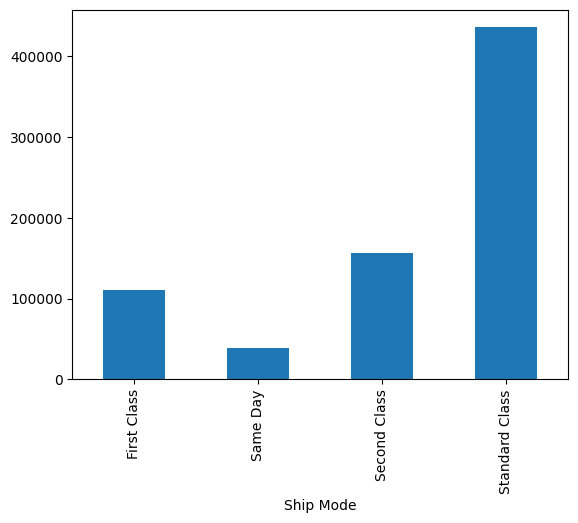

In [44]:
df.groupby("Ship Mode")["Sales"].sum().plot(kind="bar")
#standard class     اكتر حاجه بتكسب

<Axes: xlabel='Ship Mode'>

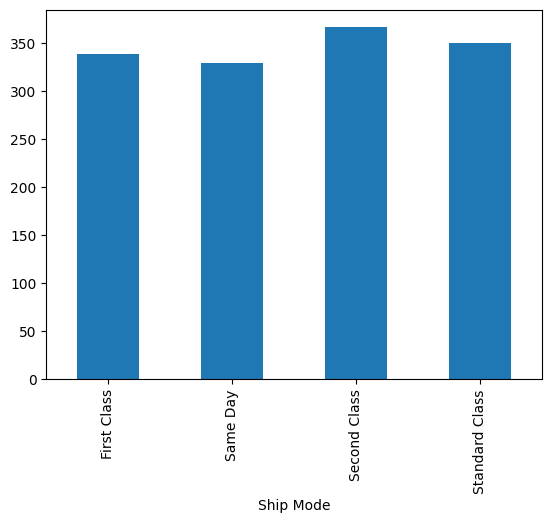

In [45]:
df.groupby("Ship Mode")["Sales"].mean().plot(kind="bar")#second class مفيد لزياده الربح

<Axes: xlabel='Segment'>

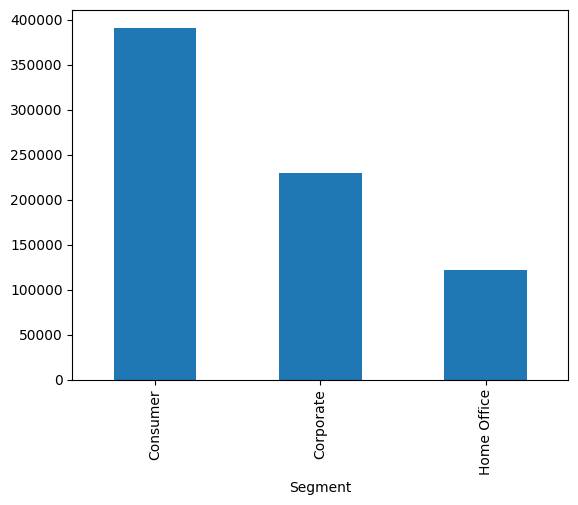

In [46]:
df.groupby("Segment")["Sales"].sum().plot(kind="bar")


<Axes: xlabel='Segment'>

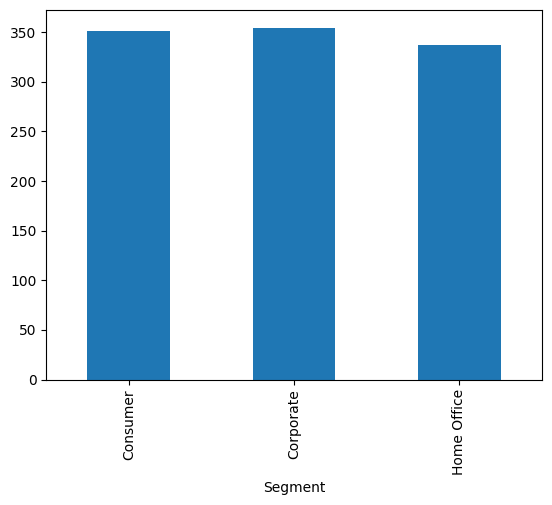

In [47]:
df.groupby("Segment")["Sales"].mean().plot(kind="bar")


In [48]:
top_cities = df.groupby("City")["Sales"].sum()
max(top_cities)
top_cities[top_cities == 75691.049]


City
New York City    75691.049
Name: Sales, dtype: float64

<Axes: xlabel='Region'>

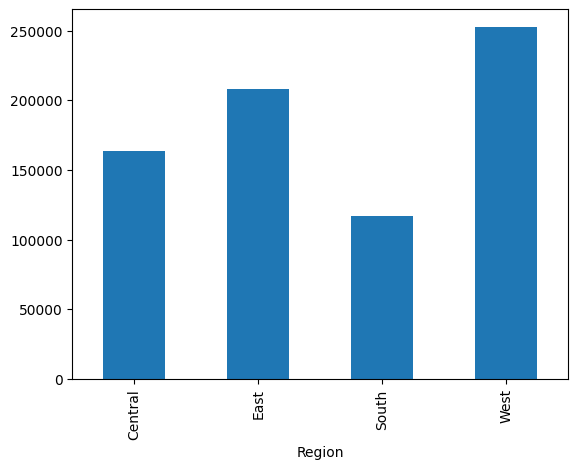

In [49]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")

<Axes: xlabel='Sub-Category'>

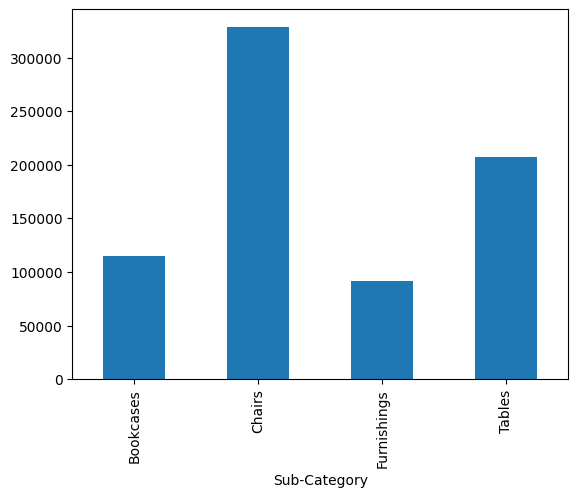

In [50]:
df.groupby("Sub-Category")["Sales"].sum().plot(kind="bar")

<Axes: xlabel='Sub-Category'>

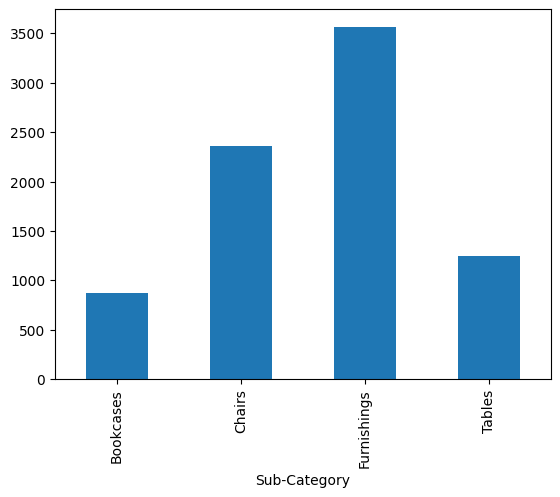

In [51]:
df.groupby("Sub-Category")["Quantity"].sum().plot(kind="bar")

<Axes: xlabel='Sub-Category'>

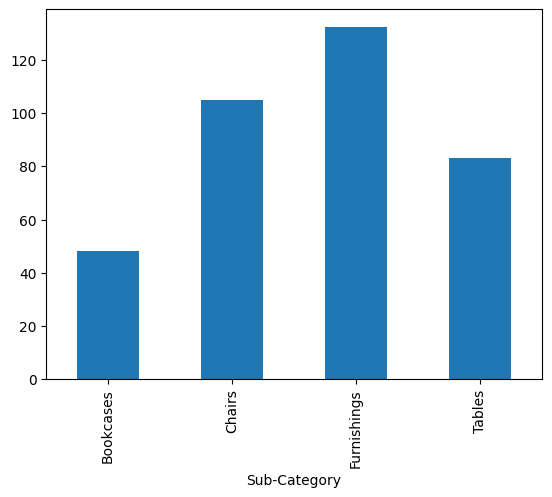

In [52]:
df.groupby("Sub-Category")["Discount"].sum().plot(kind="bar")

                   Sales     Profit  Quantity  Discount
Segment                                                
Consumer     391049.3120  6991.0786      4166    196.71
Corporate    229019.7858  7584.8158      2495    112.45
Home Office  121930.6975  3875.3784      1367     59.73
                  Sales     Profit  Quantity  Discount
Segment                                               
Consumer     351.347091   6.281293  3.743037  0.176739
Corporate    354.519792  11.741201  3.862229  0.174071
Home Office  336.825131  10.705465  3.776243  0.165000


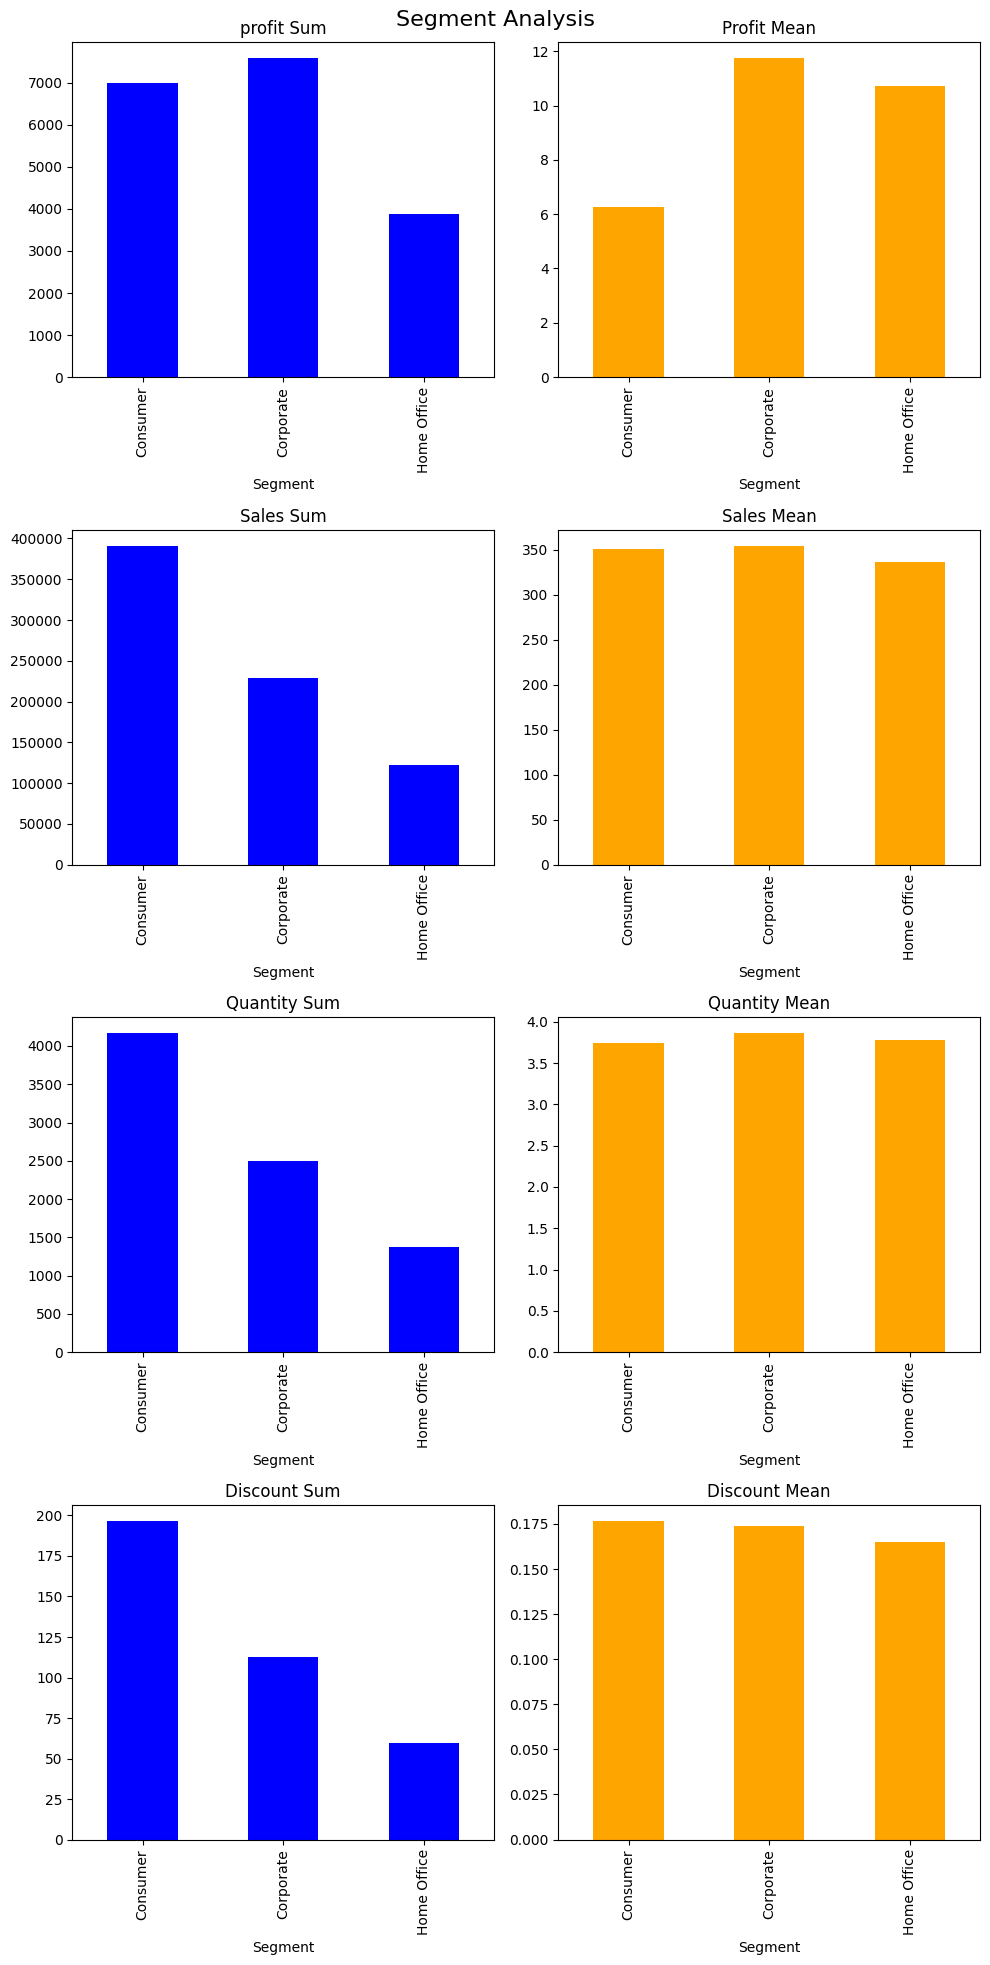

'\nConsumer  \nعلي مجمل الربح متقارب من الشريكات ولكن يختلف في الاداء العام للربح اقل فئه  \nالاعلي في مجمل المبعات \n\nCorporate  \n دي اعلي فئه في الربح من حيث الربح العام او الاداء \n\nHome Office \n الربح العام ليس الافضل ولكن في الاداء متقاربه من الشريكات \nالاقل في مجمل المبيعات كل القسام متقاربه في الاداء المبيعي \n\nملحوظه ممكن نزيد من اعدد الوحدات المباعه للكلاس الثالث لو زودنا لهم الخصمات \n\n'

In [53]:

segment_sum=df.groupby("Segment").agg({
    "Sales":"sum" ,
    "Profit":"sum" ,
    "Quantity":"sum" ,
    "Discount":"sum" ,
})

segment_mean=df.groupby("Segment").agg({
    "Sales":"mean" ,
    "Profit":"mean" ,
    "Quantity":"mean" ,
    "Discount":"mean" ,
})

print(segment_sum)
print("================================")
print(segment_mean) 

fig ,axes=plt.subplots(4,2, figsize=(10,20))
fig.suptitle("Segment Analysis", fontsize=16)

segment_sum["Profit"].plot(kind="bar", ax=axes[0,0], title="profit Sum",color="blue")
segment_mean["Profit"].plot(kind="bar", ax=axes[0,1], title="Profit Mean",color="orange")           

segment_sum["Sales"].plot(kind="bar",title="Sales Sum", ax=axes[1,0],color="blue")
segment_mean["Sales"].plot(kind="bar", ax=axes[1,1],title="Sales Mean",color="orange")

segment_sum["Quantity"].plot(kind="bar",title="Quantity Sum", ax=axes[2,0],color="blue")
segment_mean["Quantity"].plot(kind="bar", ax=axes[2,1],title="Quantity Mean",color="orange")

segment_sum["Discount"].plot(kind="bar",title="Discount Sum", ax=axes[3,0],color="blue")
segment_mean["Discount"].plot(kind="bar", ax=axes[3,1],title="Discount Mean",color="orange") 

plt.tight_layout()
plt.show()

"""
Consumer  
علي مجمل الربح متقارب من الشريكات ولكن يختلف في الاداء العام للربح اقل فئه  
الاعلي في مجمل المبعات 

Corporate  
 دي اعلي فئه في الربح من حيث الربح العام او الاداء 

Home Office 
 الربح العام ليس الافضل ولكن في الاداء متقاربه من الشريكات 
الاقل في مجمل المبيعات كل القسام متقاربه في الاداء المبيعي 

ملحوظه ممكن نزيد من اعدد الوحدات المباعه للكلاس الثالث لو زودنا لهم الخصمات 

""" 

               Sales      Profit  Quantity  Discount
Region                                              
Central  163797.1638  -2871.0494      1827    143.04
East     208291.2040   3046.1658      2214     92.60
South    117298.6840   6771.2061      1291     40.35
West     252612.7435  11504.9503      2696     92.90
              Sales     Profit  Quantity  Discount
Region                                            
Central  340.534644  -5.968918  3.798337  0.297380
East     346.574383   5.068496  3.683860  0.154077
South    353.309289  20.395199  3.888554  0.121536
West     357.302325  16.272914  3.813296  0.131400


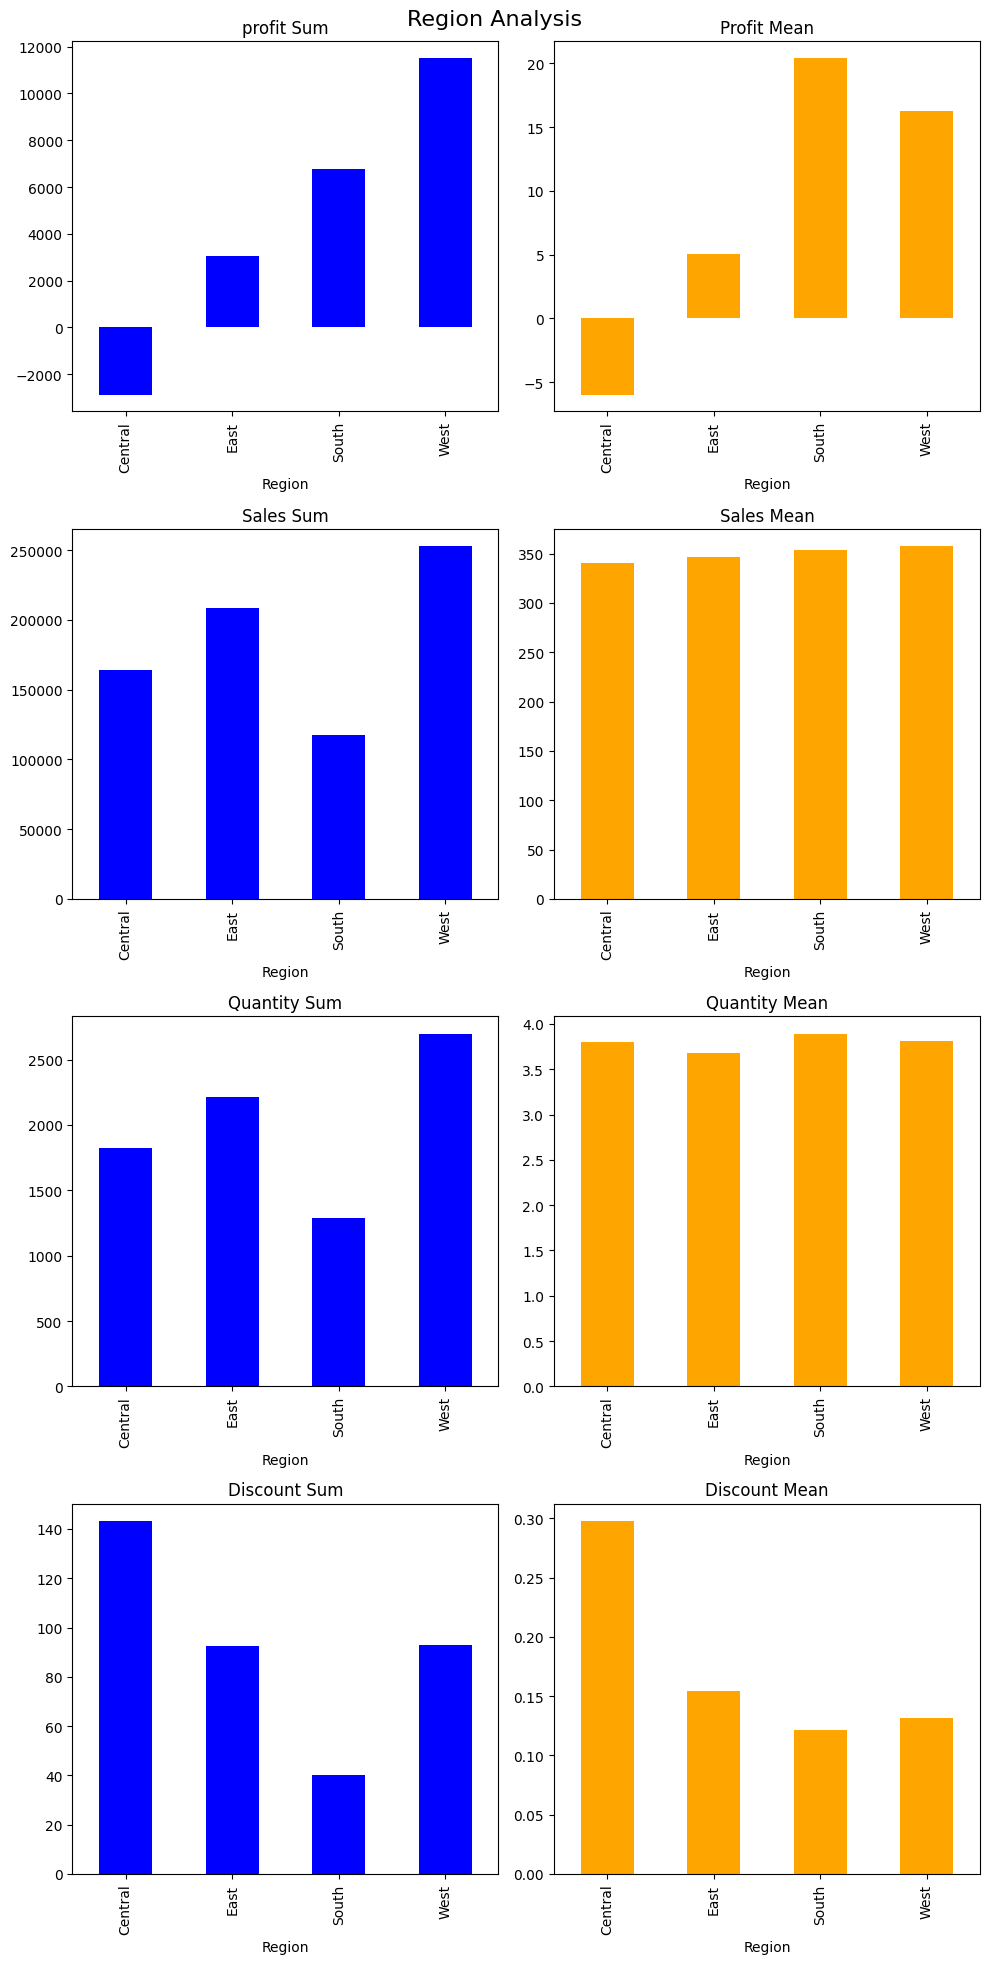

'\n\n Central  تحقق خساره فقط علي الرغم ان المبيعات كويسه و لكن يبدو ان في زياده في الخصومات\n\n\n'

In [54]:
region_sum=df.groupby("Region").agg({
    "Sales":"sum" ,
    "Profit":"sum" ,
    "Quantity":"sum" ,
    "Discount":"sum" ,
})  
region_mean=df.groupby("Region").agg({
    "Sales":"mean" ,
    "Profit":"mean" ,
    "Quantity":"mean" ,
    "Discount":"mean" ,
})

print(region_sum)
print("================================")
print(region_mean)  

fig ,axes=plt.subplots(4,2, figsize=(10,20))
fig.suptitle("Region Analysis", fontsize=16)    

region_sum["Profit"].plot(kind="bar", ax=axes[0,0], title="profit Sum",color="blue")
region_mean["Profit"].plot(kind="bar", ax=axes[0,1], title="Profit Mean",color="orange")

region_sum["Sales"].plot(kind="bar",title="Sales Sum", ax=axes[1,0],color="blue")
region_mean["Sales"].plot(kind="bar", ax=axes[1,1],title="Sales Mean",color="orange")

region_sum["Quantity"].plot(kind="bar",title="Quantity Sum", ax=axes[2,0],color="blue")
region_mean["Quantity"].plot(kind="bar", ax=axes[2,1],title="Quantity Mean",color="orange")

region_sum["Discount"].plot(kind="bar",title="Discount Sum", ax=axes[3,0],color="blue")
region_mean["Discount"].plot(kind="bar", ax=axes[3,1],title="Discount Mean",color="orange")

plt.tight_layout()
plt.show()

'''

 Central  تحقق خساره فقط علي الرغم ان المبيعات كويسه و لكن يبدو ان في زياده في الخصومات


'''  

                    Sales      Profit  Quantity  Discount
Sub-Category                                             
Bookcases     114879.9963  -3472.5560       868     48.14
Chairs        328449.1030  26590.1663      2356    105.00
Furnishings    91705.1640  13059.1436      3563    132.40
Tables        206965.5320 -17725.4811      1241     83.35
                   Sales     Profit  Quantity  Discount
Sub-Category                                           
Bookcases     503.859633 -15.230509  3.807018  0.211140
Chairs        532.332420  43.095894  3.818476  0.170178
Furnishings    95.825668  13.645918  3.723093  0.138349
Tables        648.794771 -55.565771  3.890282  0.261285


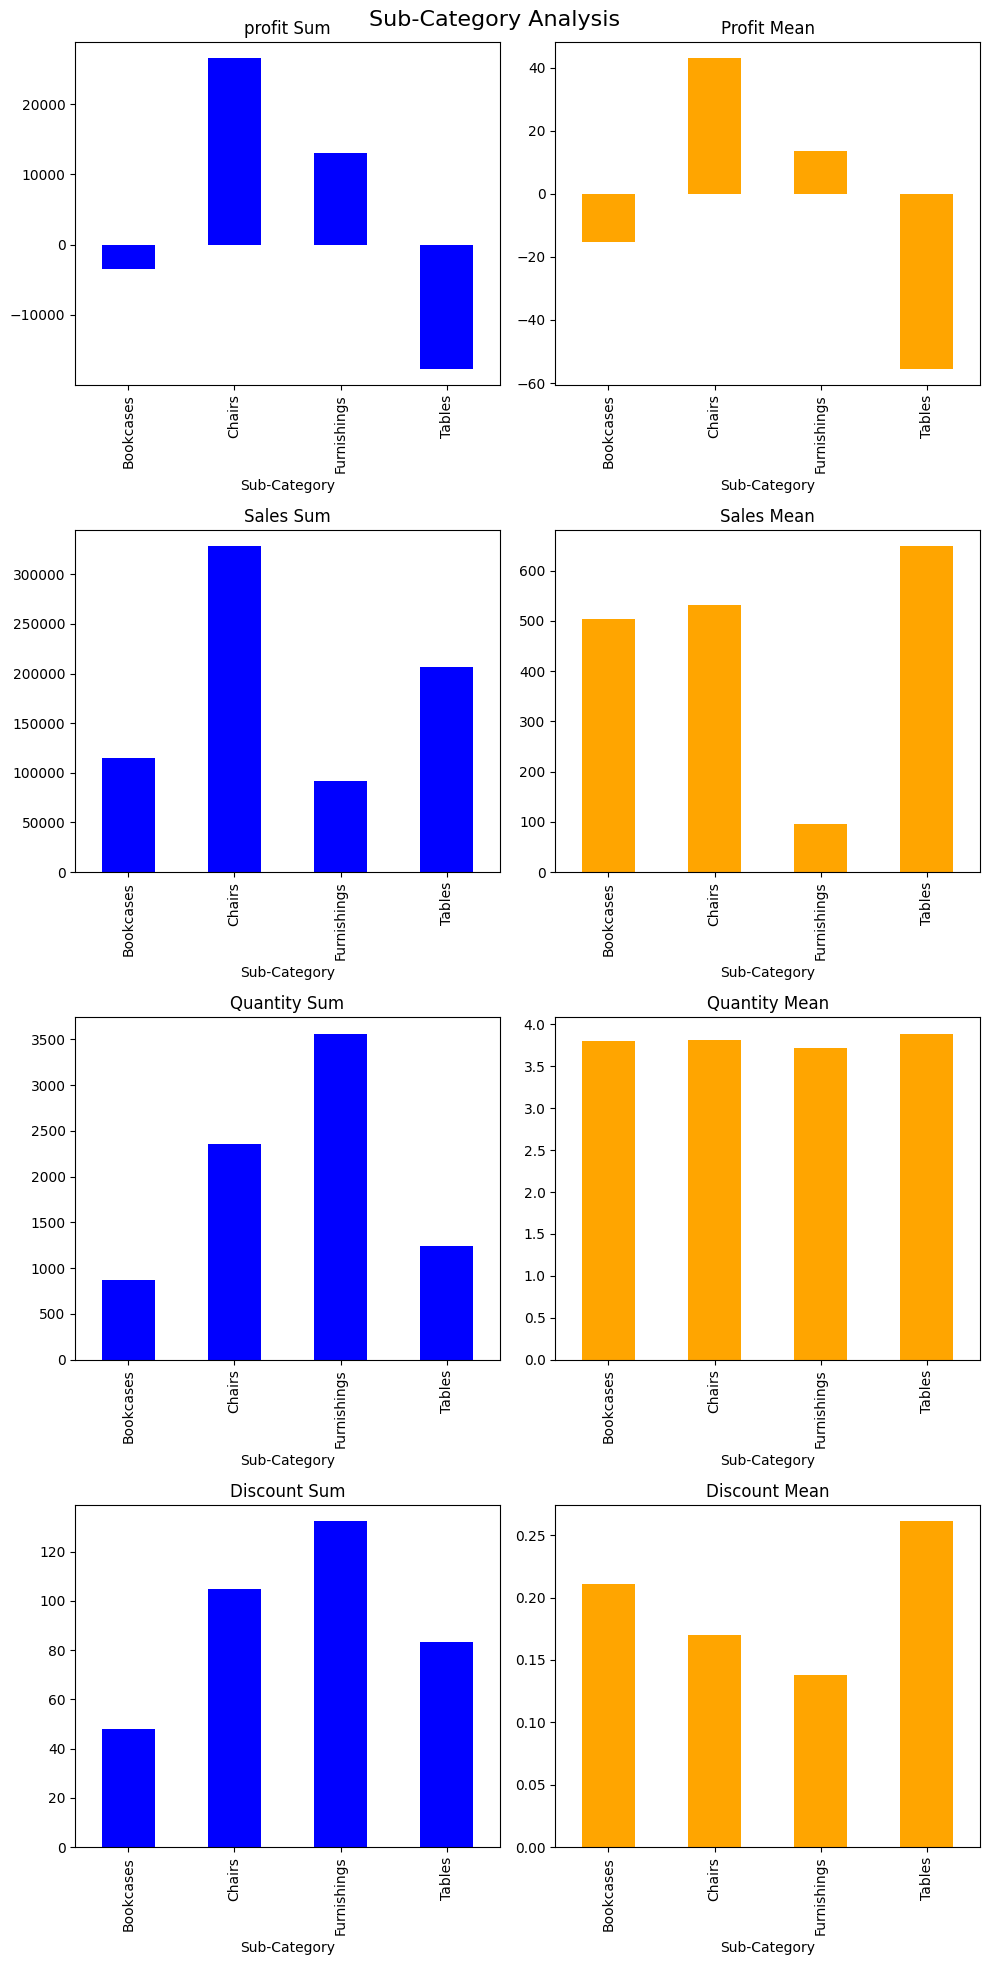

'\nالمناطق كلها هامش الربح ليس افضل حاجه ولكن افضل هامش ربح بيكون في منطقة Chairs \n\nFurnishings    اعلي منطقه في اجمالي الخصمات و في اجمالي عدد الوحدات المباعه لكن  مجمل المبيعات مقارنه بالخصمات و الاداء مش احسن حاجه \n\nChairs = ممتاز\n\nFurnishings = جيد\n\nBookcases = سلبي\n\nTables = سلبي جدًا\n'

In [55]:

sub_category_sum=df.groupby("Sub-Category").agg({
    "Sales":"sum" ,
    "Profit":"sum" ,
    "Quantity":"sum" ,
    "Discount":"sum" ,
})

sub_category_mean=df.groupby("Sub-Category").agg({
    "Sales":"mean" ,
    "Profit":"mean" ,
    "Quantity":"mean" ,
    "Discount":"mean" ,
})

print(sub_category_sum)
print("================================")
print(sub_category_mean)

fig ,axes=plt.subplots(4,2, figsize=(10,20))
fig.suptitle("Sub-Category Analysis", fontsize=16)

sub_category_sum["Profit"].plot(kind="bar", ax=axes[0,0], title="profit Sum",color="blue")
sub_category_mean["Profit"].plot(kind="bar", ax=axes[0,1], title="Profit Mean",color="orange")

sub_category_sum["Sales"].plot(kind="bar",title="Sales Sum", ax=axes[1,0],color="blue")
sub_category_mean["Sales"].plot(kind="bar", ax=axes[1,1],title="Sales Mean",color="orange")

sub_category_sum["Quantity"].plot(kind="bar",title="Quantity Sum", ax=axes[2,0],color="blue")
sub_category_mean["Quantity"].plot(kind="bar", ax=axes[2,1],title="Quantity Mean",color="orange")

sub_category_sum["Discount"].plot(kind="bar",title="Discount Sum", ax=axes[3,0],color="blue")
sub_category_mean["Discount"].plot(kind="bar", ax=axes[3,1],title="Discount Mean",color="orange")

plt.tight_layout()      
plt.show() 


'''
المناطق كلها هامش الربح ليس افضل حاجه ولكن افضل هامش ربح بيكون في منطقة Chairs 

Furnishings    اعلي منطقه في اجمالي الخصمات و في اجمالي عدد الوحدات المباعه لكن  مجمل المبيعات مقارنه بالخصمات و الاداء مش احسن حاجه 

Chairs = ممتاز

Furnishings = جيد

Bookcases = سلبي

Tables = سلبي جدًا
'''

                     Sales     Profit  Quantity  Ship Mode
Shipping Time                                             
0               37004.6830   539.3812       437        116
1               25113.8272   784.1449       283         77
2              124888.1230  7483.8962      1192        310
3               58159.1388  -299.0490       705        186
4              212148.6543  4890.3760      2310        601
5              161316.7147   137.9456      1700        466
6               80647.7318  4108.4705       928        236
7               42720.9225   806.1074       473        129


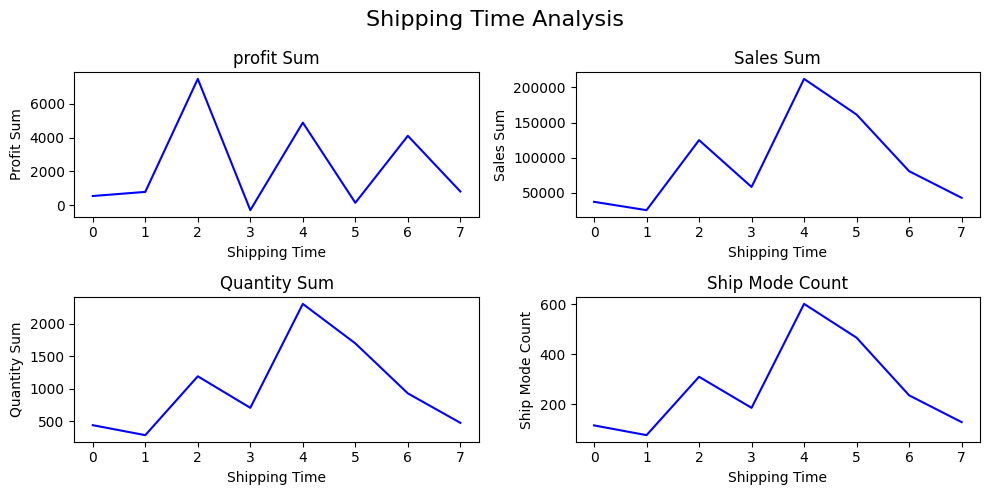

'\nالعملاء يفضلو وصول المنتجات في فتره من 3 الي 5 ايام \n\nاعلي  ربح دخل كان من خلال الوصيل الي بخد 2 يوم \n'

In [56]:

pest_Shipping_Time=df.groupby("Shipping Time").agg({
    "Sales":"sum" ,
    "Profit":"sum" ,
    "Quantity":"sum" ,
    "Ship Mode":"count"
})
print(pest_Shipping_Time)
fig ,axes=plt.subplots(2,2, figsize=(10,5))
fig.suptitle("Shipping Time Analysis", fontsize=16)

pest_Shipping_Time["Profit"].plot(kind="line", ax=axes[0,0], title="profit Sum",color="blue",xlabel="Shipping Time",ylabel="Profit Sum")
pest_Shipping_Time["Sales"].plot(kind="line",title="Sales Sum", ax=axes[0,1],color="blue",xlabel="Shipping Time",ylabel="Sales Sum")
pest_Shipping_Time["Quantity"].plot(kind="line",title="Quantity Sum", ax=axes[1,0],color="blue",xlabel="Shipping Time",ylabel="Quantity Sum")
pest_Shipping_Time["Ship Mode"].plot(kind="line",title="Ship Mode Count", ax=axes[1,1],color="blue",xlabel="Shipping Time",ylabel="Ship Mode Count")      
plt.tight_layout()      
plt.show()

"""
العملاء يفضلو وصول المنتجات في فتره من 3 الي 5 ايام 

اعلي  ربح دخل كان من خلال الوصيل الي بخد 2 يوم 
""" 

                      Sales      Profit  Quantity
Ship Mode                                        
First Class     110730.5229   3066.9474      1238
Same Day         39148.7790    797.3484       453
Second Class    156289.0244   4226.2614      1569
Standard Class  435831.4690  10360.7156      4768
                     Sales    Profit  Quantity
Ship Mode                                     
First Class     338.625452  9.379044  3.785933
Same Day        328.981336  6.700407  3.806723
Second Class    366.016451  9.897568  3.674473
Standard Class  349.223933  8.301855  3.820513


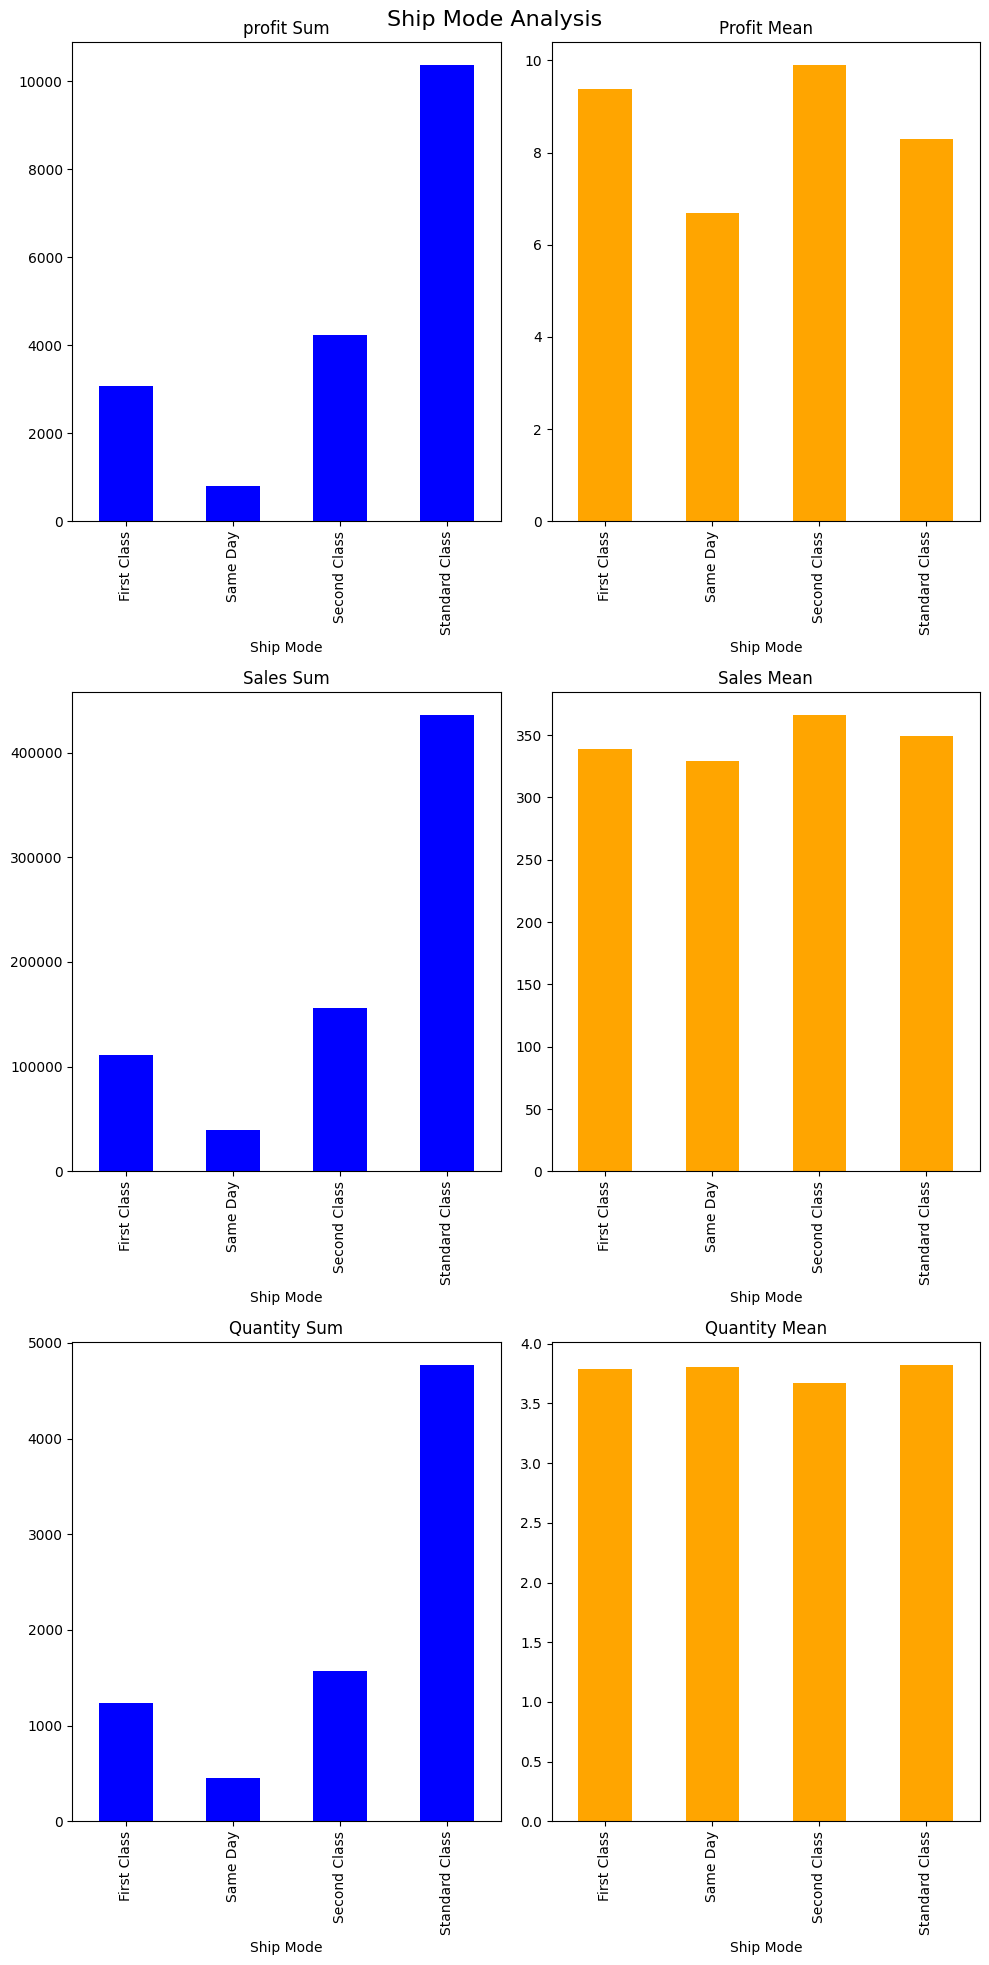

Ship Mode
First Class        327
Same Day           119
Second Class       427
Standard Class    1248
Name: Quantity, dtype: int64


'\nاهم نظام شحن عندنا هو standard class\nstanser class  اعلي  مبيعات و ربح كان من خلاله \nلكن افضل داء ربح كان من خلال second class'

In [57]:
ship_mode_sum=df.groupby("Ship Mode").agg({
    "Sales":"sum" ,
    "Profit":"sum" ,
    "Quantity":"sum" ,
})

ship_mode_mean=df.groupby("Ship Mode").agg({
    "Sales":"mean" ,
    "Profit":"mean" ,
    "Quantity":"mean" ,
})  


print(ship_mode_sum)
print("================================")
print(ship_mode_mean)


fig ,axes=plt.subplots(3,2, figsize=(10,20))
fig.suptitle("Ship Mode Analysis", fontsize=16)

ship_mode_sum["Profit"].plot(kind="bar", ax=axes[0,0], title="profit Sum",color="blue")
ship_mode_mean["Profit"].plot(kind="bar", ax=axes[0,1], title="Profit Mean",color="orange")

ship_mode_sum["Sales"].plot(kind="bar",title="Sales Sum", ax=axes[1,0],color="blue")
ship_mode_mean["Sales"].plot(kind="bar", ax=axes[1,1],title="Sales Mean",color="orange")

ship_mode_sum["Quantity"].plot(kind="bar",title="Quantity Sum", ax=axes[2,0],color="blue")
ship_mode_mean["Quantity"].plot(kind="bar", ax=axes[2,1],title="Quantity Mean",color="orange")

plt.tight_layout()
plt.show()
print(df.groupby("Ship Mode")["Quantity"].count())

"""
اهم نظام شحن عندنا هو standard class
stanser class  اعلي  مبيعات و ربح كان من خلاله 
لكن افضل داء ربح كان من خلال second class"""


<Axes: xlabel='Shipping Time'>

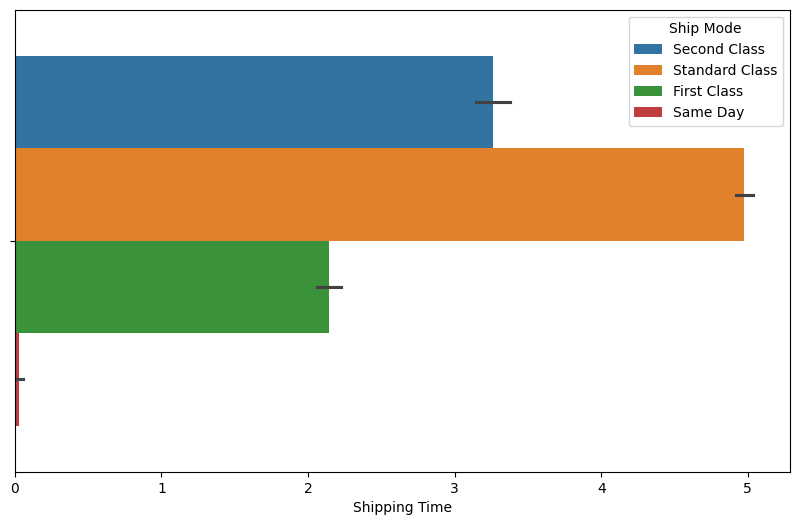

In [58]:

#عوزين نعرف كل توصيل بخد كام يوم 
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Shipping Time", hue="Ship Mode") 

In [59]:
from dash import Dash, html, dcc, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd


df['Shipping Time'] = pd.Categorical(df['Shipping Time'], ordered=True)

# ---------- Dashboard ----------
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

# ---------- Ship Mode Figures ----------
fig_ship_sales_sum = px.bar(ship_mode_sum, x=ship_mode_sum.index, y="Sales", title="Ship Mode Sales Sum", color=ship_mode_sum.index)
fig_ship_sales_mean = px.bar(ship_mode_mean, x=ship_mode_mean.index, y="Sales", title="Ship Mode Sales Mean", color=ship_mode_mean.index)
fig_ship_profit_sum = px.bar(ship_mode_sum, x=ship_mode_sum.index, y="Profit", title="Ship Mode Profit Sum", color=ship_mode_sum.index)
fig_ship_profit_mean = px.bar(ship_mode_mean, x=ship_mode_mean.index, y="Profit", title="Ship Mode Profit Mean", color=ship_mode_mean.index)
fig_ship_quantity_sum = px.bar(ship_mode_sum, x=ship_mode_sum.index, y="Quantity", title="Ship Mode Quantity Sum", color=ship_mode_sum.index)

# ---------- Segment Figures ----------
fig_segment_sales_sum = px.bar(segment_sum, x=segment_sum.index, y="Sales", title="Segment Sales Sum", color=segment_sum.index)
fig_segment_quantity_sum = px.bar(segment_sum, x=segment_sum.index, y="Quantity", title="Segment Quantity Sum", color=segment_sum.index)
fig_segment_discount_sum = px.bar(segment_sum, x=segment_sum.index, y="Discount", title="Segment Discount Sum", color=segment_sum.index)
fig_segment_profit_sum = px.bar(segment_sum, x=segment_sum.index, y="Profit", title="Segment Profit Sum", color=segment_sum.index)
fig_segment_profit_mean = px.bar(segment_mean, x=segment_mean.index, y="Profit", title="Segment Profit Mean", color=segment_mean.index)

# ---------- Region Figures ----------
fig_region_sales_sum = px.bar(region_sum, x=region_sum.index, y="Sales", title="Region Sales Sum", color=region_sum.index)
fig_region_quantity_sum = px.bar(region_sum, x=region_sum.index, y="Quantity", title="Region Quantity Sum", color=region_sum.index)
fig_region_discount_sum = px.bar(region_sum, x=region_sum.index, y="Discount", title="Region Discount Sum", color=region_sum.index)
fig_region_profit_sum = px.bar(region_sum, x=region_sum.index, y="Profit", title="Region Profit Sum", color=region_sum.index)
fig_region_profit_mean = px.bar(region_mean, x=region_mean.index, y="Profit", title="Region Profit Mean", color=region_mean.index)

# ---------- Sub-Category Figures ----------
fig_subcat_sales_sum = px.bar(sub_category_sum, x=sub_category_sum.index, y="Sales", title="Sub-Category Sales Sum", color=sub_category_sum.index)
fig_subcat_quantity_sum = px.bar(sub_category_sum, x=sub_category_sum.index, y="Quantity", title="Sub-Category Quantity Sum", color=sub_category_sum.index)
fig_subcat_discount_sum = px.bar(sub_category_sum, x=sub_category_sum.index, y="Discount", title="Sub-Category Discount Sum", color=sub_category_sum.index)
fig_subcat_profit_sum = px.bar(sub_category_sum, x=sub_category_sum.index, y="Profit", title="Sub-Category Profit Sum", color=sub_category_sum.index)
fig_subcat_profit_mean = px.bar(sub_category_mean, x=sub_category_mean.index, y="Profit", title="Sub-Category Profit Mean", color=sub_category_mean.index)

# ---------- Shipping Time Figures ----------
fig_shipping_time = go.Figure()
fig_shipping_time.add_trace(go.Scatter(x=pest_Shipping_Time.index, y=pest_Shipping_Time["Profit"], mode="lines+markers", name="Profit"))
fig_shipping_time.add_trace(go.Scatter(x=pest_Shipping_Time.index, y=pest_Shipping_Time["Sales"], mode="lines+markers", name="Sales"))
fig_shipping_time.add_trace(go.Scatter(x=pest_Shipping_Time.index, y=pest_Shipping_Time["Quantity"], mode="lines+markers", name="Quantity"))
fig_shipping_time.add_trace(go.Scatter(x=pest_Shipping_Time.index, y=pest_Shipping_Time["Ship Mode"], mode="lines+markers", name="Ship Mode Count"))
fig_shipping_time.update_layout(title="Shipping Time Analysis", xaxis_title="Shipping Time (Days)")

# Shipping Time vs Ship Mode breakdown
fig_shipping_time_hue = px.bar(
    df,
    x="Shipping Time",
    color="Ship Mode",
    barmode="group",
    title="Shipping Time by Ship Mode",
    color_discrete_sequence=px.colors.qualitative.Set2,
    text_auto=True
)

fig_shipping_time_hue.update_layout(
    xaxis_title="Shipping Time (Days)",
    yaxis_title="Number of Orders",
    xaxis=dict(tickmode="linear")
)

# ---------- Layout ----------
app.layout = html.Div([
    html.H1("Stores Sales Analysis Dashboard", style={"textAlign": "center", "color": "#007BFF"}),

    html.H2("Ship Mode Analysis", style={"color": "#007BFF"}),
    dcc.Graph(figure=fig_ship_sales_sum),
    dcc.Graph(figure=fig_ship_sales_mean),
    dcc.Graph(figure=fig_ship_quantity_sum),
    dcc.Graph(figure=fig_ship_profit_sum),
    dcc.Graph(figure=fig_ship_profit_mean),

    html.H2("Segment Analysis", style={"color": "#007BFF"}),
    dcc.Graph(figure=fig_segment_sales_sum),
    dcc.Graph(figure=fig_segment_quantity_sum),
    dcc.Graph(figure=fig_segment_discount_sum),
    dcc.Graph(figure=fig_segment_profit_sum),
    dcc.Graph(figure=fig_segment_profit_mean),

    html.H2("Region Analysis", style={"color": "#007BFF"}),
    dcc.Graph(figure=fig_region_sales_sum),
    dcc.Graph(figure=fig_region_quantity_sum),
    dcc.Graph(figure=fig_region_discount_sum),
    dcc.Graph(figure=fig_region_profit_sum),
    dcc.Graph(figure=fig_region_profit_mean),

    html.H2("Sub-Category Analysis", style={"color": "#007BFF"}),
    dcc.Graph(figure=fig_subcat_sales_sum),
    dcc.Graph(figure=fig_subcat_quantity_sum),
    dcc.Graph(figure=fig_subcat_discount_sum),
    dcc.Graph(figure=fig_subcat_profit_sum),
    dcc.Graph(figure=fig_subcat_profit_mean),

    html.H2("Shipping Time Analysis", style={"color": "#007BFF"}),
    dcc.Graph(figure=fig_shipping_time),
    dcc.Graph(figure=fig_shipping_time_hue),

    html.H2("Data Table", style={"color": "#007BFF"}),
    dash_table.DataTable(
        df.to_dict('records'),
        [{"name": i, "id": i} for i in df.columns],
        page_size=10,
        style_table={'overflowX': 'auto'}
    )
])

# ---------- تشغيل الداشبورد ----------
if __name__ == '__main__':
    app.run(debug=True)